#**Task 2: Customer Segmentation Using Unsupervised Learning**

## **1. Problem Statement and Objective**

### **Problem Statement**

Businesses often serve customers with different income levels, spending behaviors, and purchasing preferences. Treating all customers the same can lead to inefficient marketing, poor customer engagement, and wasted advertising budget.

Customer segmentation helps businesses divide customers into meaningful groups based on similar characteristics.

### **Objective**

The objective of this task is to cluster mall customers based on their spending habits using unsupervised learning.

The main goals are:

1. Load and explore the Mall Customers dataset.
2. Clean and preprocess the data.
3. Perform Exploratory Data Analysis.
4. Apply K-Means Clustering.
5. Use the Elbow Method and Silhouette Score to select the best number of clusters.
6. Visualize clusters using PCA and t-SNE.
7. Interpret each customer segment.
8. Suggest marketing strategies for each segment.

### **Import Required Libraries**

In [2]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

### **Load the Dataset**
#### **Dataset Description**

The Mall Customers Dataset contains customer information collected from a shopping mall.

Common columns include:

| Column                 | Description                                                               |
| ---------------------- | ------------------------------------------------------------------------- |
| CustomerID             | Unique ID assigned to each customer                                       |
| Gender                 | Gender of the customer                                                    |
| Age                    | Age of the customer                                                       |
| Annual Income (k$)     | Annual income of the customer in thousand dollars                         |
| Spending Score (1-100) | Score assigned by the mall based on customer behavior and spending nature |

The most important variables for segmentation are usually:

* **Annual Income**
* **Spending Score**
* **Age**
* **Gender**

In [3]:
# Load the Excel file directly
df = pd.read_excel("Mall Customers.xlsx")

# Display first five rows
df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


### **Basic Dataset Exploration**

In [4]:
# Check dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Dataset information
df.info()

# Statistical summary of numerical columns
df.describe()

Number of rows: 200
Number of columns: 7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Education               200 non-null    object
 4   Marital Status          200 non-null    object
 5   Annual Income (k$)      200 non-null    int64 
 6   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 11.1+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### **Changing Column Names**

In [5]:
# Rename columns for easier use
df = df.rename(columns={
    "CustomerID": "customer_id",
    "Gender": "gender",
    "Age": "age",
    "Annual Income (k$)": "annual_income",
    "Spending Score (1-100)": "spending_score"
})

df.head()

,customer_id,gender,age,Education,Marital Status,annual_income,spending_score
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


### **Data Cleaning**

In [6]:
# Check missing values
df.isnull().sum()

# Check duplicate rows
df.duplicated().sum()

# Remove duplicate rows if any
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

# Check data types
df.dtypes

Dataset shape after removing duplicates: (200, 7)


,0
customer_id,int64
gender,object
age,int64
Education,object
Marital Status,object
annual_income,int64
spending_score,int64


### **Encode Categorical Features**

In [7]:
# Encode gender column
df["gender_encoded"] = df["gender"].map({
    "M": 0,
    "F": 1
})

df.head()

,customer_id,gender,age,Education,Marital Status,annual_income,spending_score,gender_encoded
0,1,M,19,High School,Married,15,39,0
1,2,M,21,Graduate,Single,15,81,0
2,3,F,20,Graduate,Married,16,6,1
3,4,F,23,High School,Unknown,16,77,1
4,5,F,31,Uneducated,Married,17,40,1


## **2. Exploratory Data Analysis**

### **Gender Distribution**

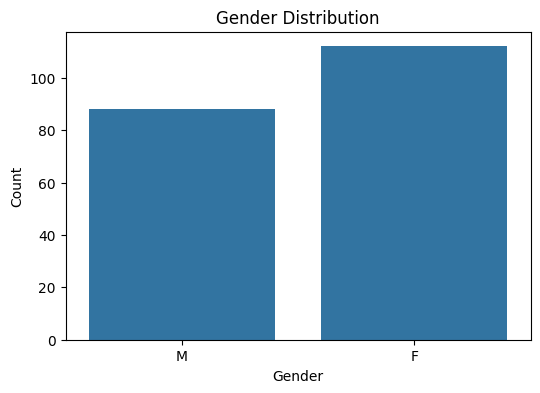

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="gender")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

### **Age Distribution**

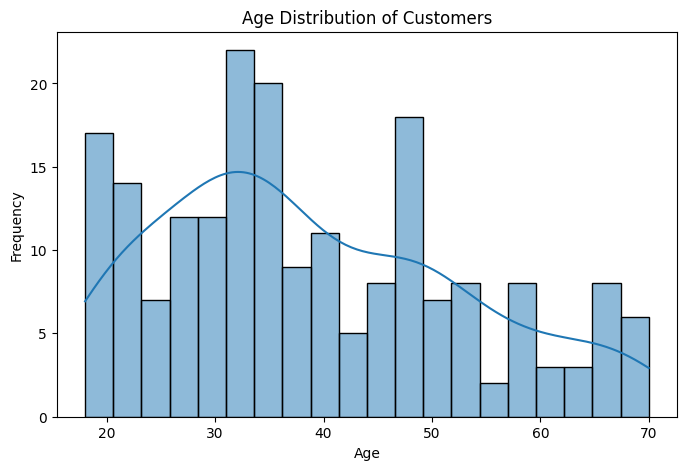

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### ** Annual Income Distribution**

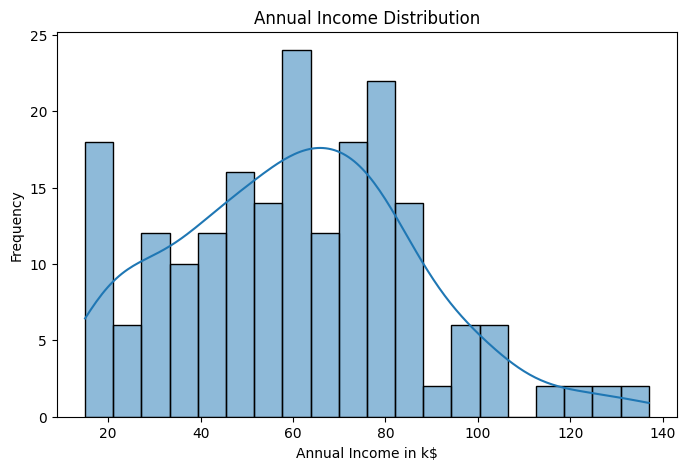

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df["annual_income"], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income in k$")
plt.ylabel("Frequency")
plt.show()

### **Spending Score Distribution**

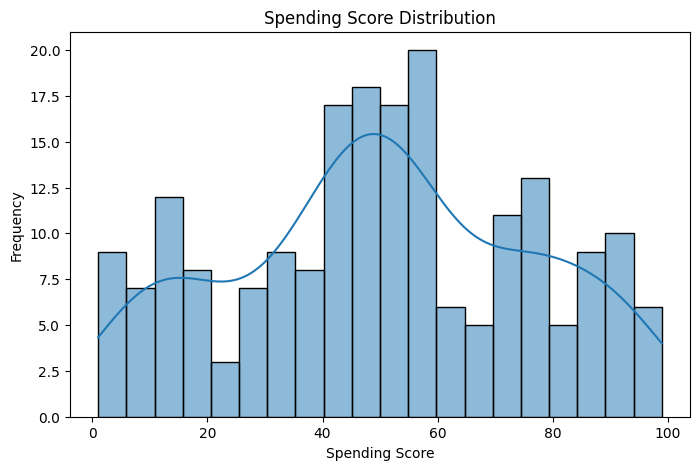

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df["spending_score"], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Frequency")
plt.show()

### **Income vs Spending Score**

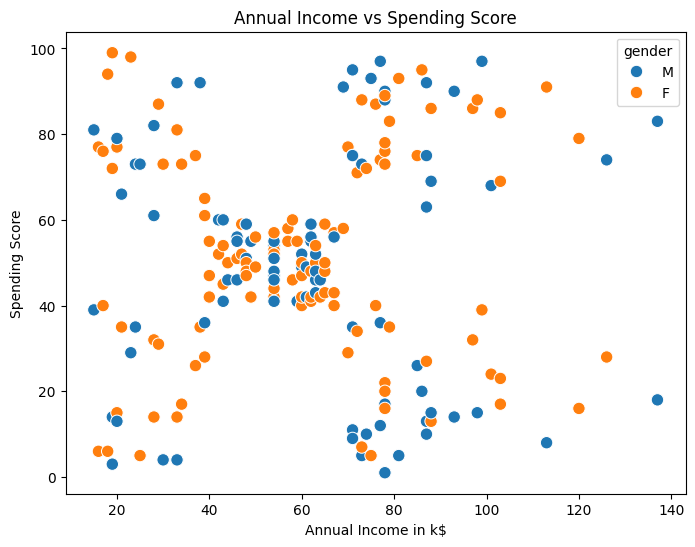

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="annual_income",
    y="spending_score",
    hue="gender",
    s=80
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income in k$")
plt.ylabel("Spending Score")
plt.show()

### **Age vs Spending Score**

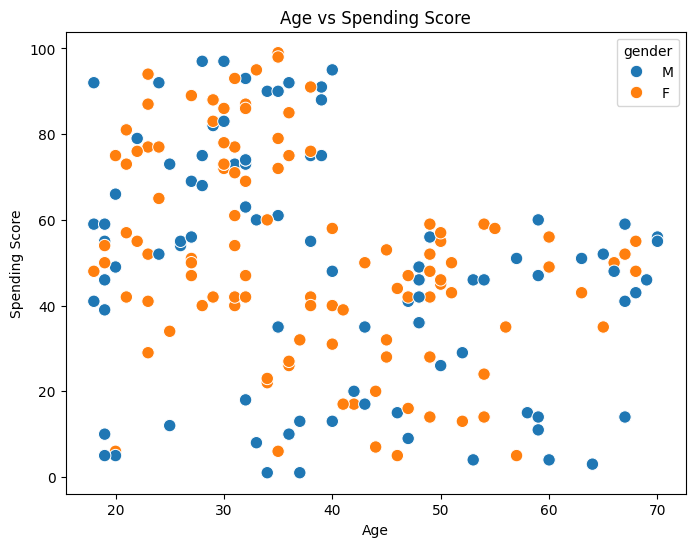

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="age",
    y="spending_score",
    hue="gender",
    s=80
)

plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.show()

### **Correlation Heatmap**

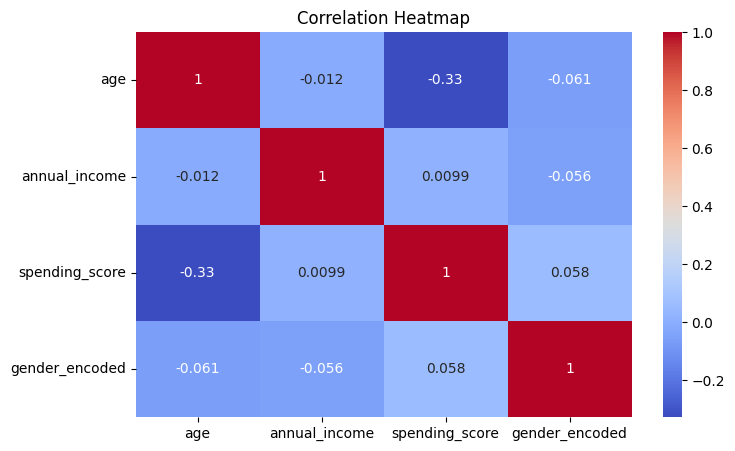

In [14]:
# Select numerical columns
numeric_df = df[["age", "annual_income", "spending_score", "gender_encoded"]]

plt.figure(figsize=(8, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## **3. Feature Selection and Preprocessing**

For customer segmentation, we will use the following features:

1. Age
2. Annual Income
3. Spending Score
4. Gender Encoded

However, for the main marketing segmentation, **Annual Income** and **Spending Score** are usually the most meaningful features.

We will first cluster using:

* `annual_income`
* `spending_score`

Then we will also use PCA/t-SNE for visualization.

### **Select Features for Clustering**

In [15]:
# Select features for clustering
X = df[["annual_income", "spending_score"]]

X.head()

,annual_income,spending_score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


### **Feature Scaling**
K-Means is distance-based, so scaling is important.

In [16]:
# Scale the selected features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data into DataFrame
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=["annual_income_scaled", "spending_score_scaled"]
)

X_scaled_df.head()

,annual_income_scaled,spending_score_scaled
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


## **4. K-Means Clustering**


### **Elbow Method**

The Elbow Method helps us choose the best number of clusters by checking the Within-Cluster Sum of Squares.


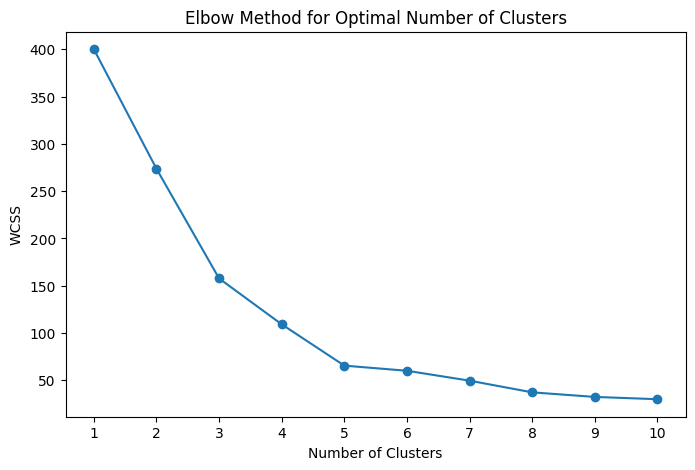

In [17]:
# Calculate WCSS for different values of k
wcss = []

k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.xticks(k_values)
plt.show()

### **Silhouette Score**

The Silhouette Score checks how well-separated the clusters are. A higher score is better.

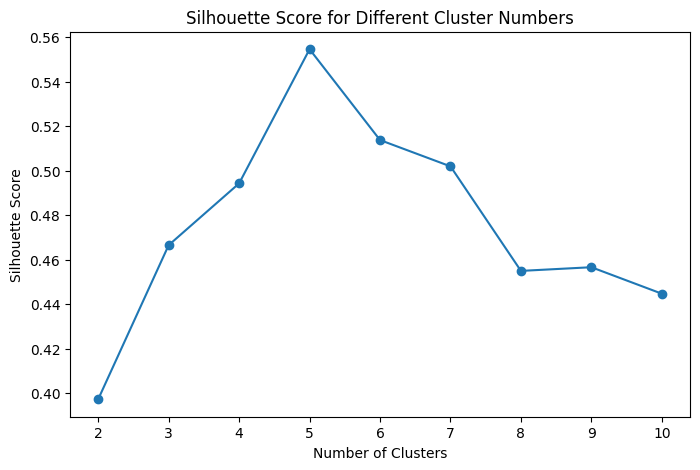

,Number of Clusters,Silhouette Score
0,2,0.397327
1,3,0.466585
2,4,0.494350
3,5,0.554657
4,6,0.513826
5,7,0.502001
6,8,0.455011
7,9,0.456662
8,10,0.444760


In [20]:
# Calculate silhouette scores for k = 2 to 10
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.title("Silhouette Score for Different Cluster Numbers")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.show()

# Display silhouette scores in table form
silhouette_df = pd.DataFrame({
    "Number of Clusters": range(2, 11),
    "Silhouette Score": silhouette_scores
})

silhouette_df

### **Apply Final K-Means Model**
For the Mall Customers Dataset, the ideal number of clusters is commonly **5**, especially when using `annual_income` and `spending_score`.


In [21]:
# Apply K-Means with 5 clusters
final_kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42
)

df["cluster"] = final_kmeans.fit_predict(X_scaled)
df.head()

,customer_id,gender,age,Education,Marital Status,annual_income,spending_score,gender_encoded,cluster
0,1,M,19,High School,Married,15,39,0,4
1,2,M,21,Graduate,Single,15,81,0,2
2,3,F,20,Graduate,Married,16,6,1,4
3,4,F,23,High School,Unknown,16,77,1,2
4,5,F,31,Uneducated,Married,17,40,1,4


## **Cluster Centers**


In [22]:
# Get cluster centers in scaled form
cluster_centers_scaled = final_kmeans.cluster_centers_

# Convert cluster centers back to original scale
cluster_centers_original = scaler.inverse_transform(cluster_centers_scaled)

cluster_centers_df = pd.DataFrame(
    cluster_centers_original,
    columns=["annual_income", "spending_score"]
)

cluster_centers_df["cluster"] = range(5)

cluster_centers_df

,annual_income,spending_score,cluster
0,55.296296,49.518519,0
1,86.538462,82.128205,1
2,25.727273,79.363636,2
3,88.200000,17.114286,3
4,26.304348,20.913043,4


## **5. Cluster Visualization**
### **Visualize Customer Segments**

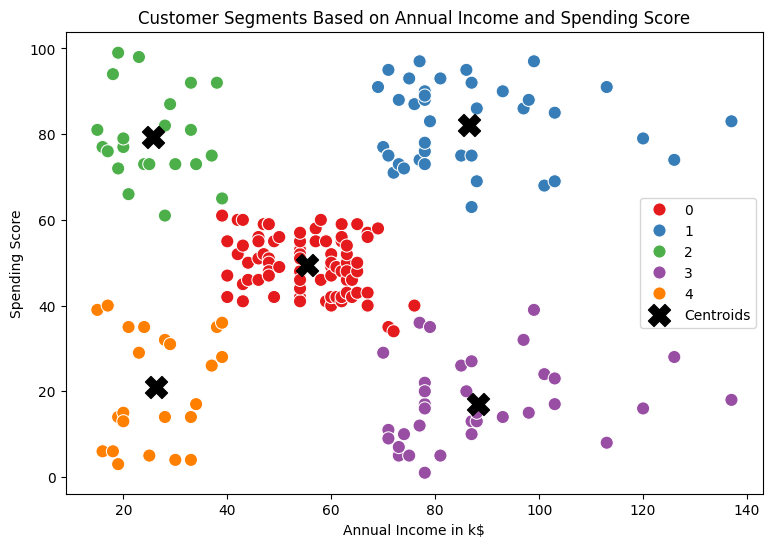

In [23]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="annual_income",
    y="spending_score",
    hue="cluster",
    palette="Set1",
    s=90
)

# Plot cluster centers
plt.scatter(
    cluster_centers_df["annual_income"],
    cluster_centers_df["spending_score"],
    s=250,
    c="black",
    marker="X",
    label="Centroids"
)

plt.title("Customer Segments Based on Annual Income and Spending Score")
plt.xlabel("Annual Income in k$")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

### **Number of Customers in Each Cluster**

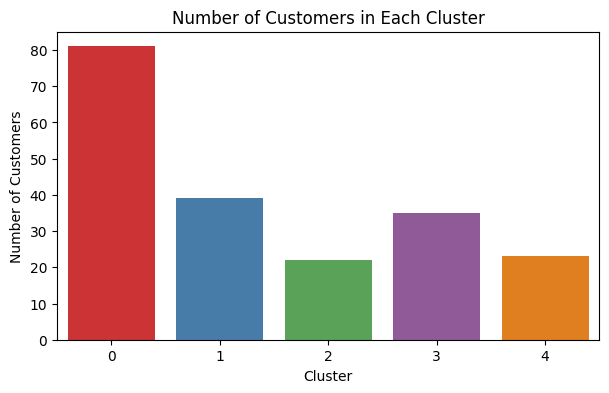

In [25]:
cluster_counts = df["cluster"].value_counts().sort_index()

cluster_counts

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="cluster", palette="Set1")
plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

## **6. Cluster Profiling**
### **Cell 22 — Average Values by Cluster**

In [27]:
cluster_profile = df.groupby("cluster").agg({
    "age": "mean",
    "annual_income": "mean",
    "spending_score": "mean",
    "gender_encoded": "mean",
    "customer_id": "count"
}).rename(columns={
    "customer_id": "customer_count"
})

cluster_profile

,age,annual_income,spending_score,gender_encoded,customer_count
cluster,,,,,
0,42.716049,55.296296,49.518519,0.592593,81
1,32.692308,86.538462,82.128205,0.538462,39
2,25.272727,25.727273,79.363636,0.590909,22
3,41.114286,88.200000,17.114286,0.457143,35
4,45.217391,26.304348,20.913043,0.608696,23


### **Better Cluster Labels**
Now we assign business-friendly names to the clusters.

The exact cluster numbers may vary slightly depending on the model, so we will inspect the average values first and then assign labels logically.

In [28]:
def label_cluster(row):
    income = row["annual_income"]
    spending = row["spending_score"]

    if income >= 70 and spending >= 60:
        return "High Income - High Spending"
    elif income >= 70 and spending < 40:
        return "High Income - Low Spending"
    elif income < 45 and spending >= 60:
        return "Low Income - High Spending"
    elif income < 45 and spending < 40:
        return "Low Income - Low Spending"
    else:
        return "Medium Income - Medium Spending"

# Create cluster label mapping based on cluster profile
cluster_profile_reset = cluster_profile.reset_index()
cluster_profile_reset["segment_name"] = cluster_profile_reset.apply(label_cluster, axis=1)

cluster_profile_reset

# Create dictionary to map cluster number to segment name
cluster_label_map = dict(zip(
    cluster_profile_reset["cluster"],
    cluster_profile_reset["segment_name"]
))

# Apply segment names to original dataset
df["segment_name"] = df["cluster"].map(cluster_label_map)

df.head()

,customer_id,gender,age,Education,Marital Status,annual_income,spending_score,gender_encoded,cluster,segment_name
0,1,M,19,High School,Married,15,39,0,4,Low Income - Low Spending
1,2,M,21,Graduate,Single,15,81,0,2,Low Income - High Spending
2,3,F,20,Graduate,Married,16,6,1,4,Low Income - Low Spending
3,4,F,23,High School,Unknown,16,77,1,2,Low Income - High Spending
4,5,F,31,Uneducated,Married,17,40,1,4,Low Income - Low Spending


### **Segment Distribution**

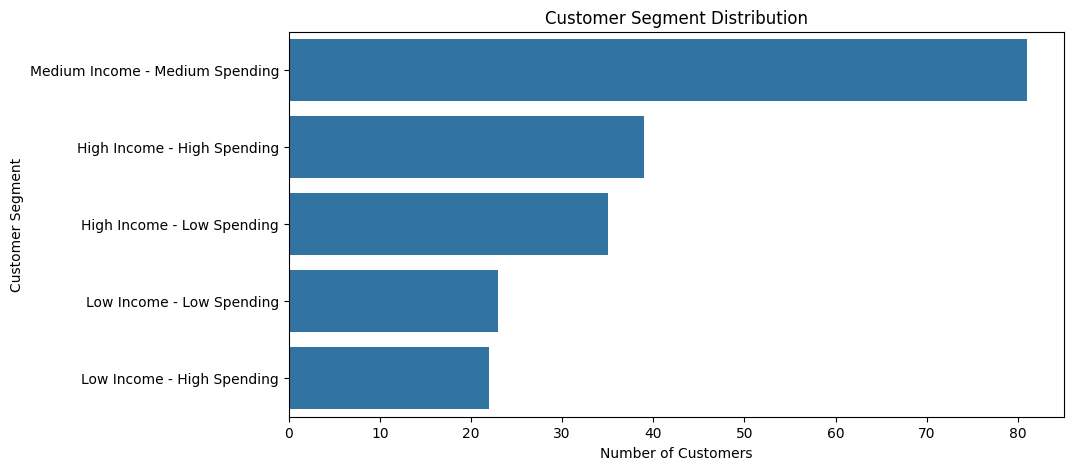

In [29]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    y="segment_name",
    order=df["segment_name"].value_counts().index
)

plt.title("Customer Segment Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")
plt.show()

## **7. PCA Visualization**

PCA is used to reduce the feature space into two dimensions so that clusters can be visualized more easily.

Since we already used two features, PCA is more useful when using multiple features.

Now we will use:

* Gender Encoded
* Age
* Annual Income
* Spending Score

### **Multi-Feature Clustering Dataset**

In [30]:
# Select multiple features for PCA visualization
X_multi = df[["gender_encoded", "age", "annual_income", "spending_score"]]

# Scale features
multi_scaler = StandardScaler()
X_multi_scaled = multi_scaler.fit_transform(X_multi)

### **Apply PCA**

In [31]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_multi_scaled)

# Add PCA components to dataframe
df["pca_1"] = X_pca[:, 0]
df["pca_2"] = X_pca[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.33690046 0.26230645]
Total explained variance: 0.5992069019819846


### **PCA Cluster Visualization**

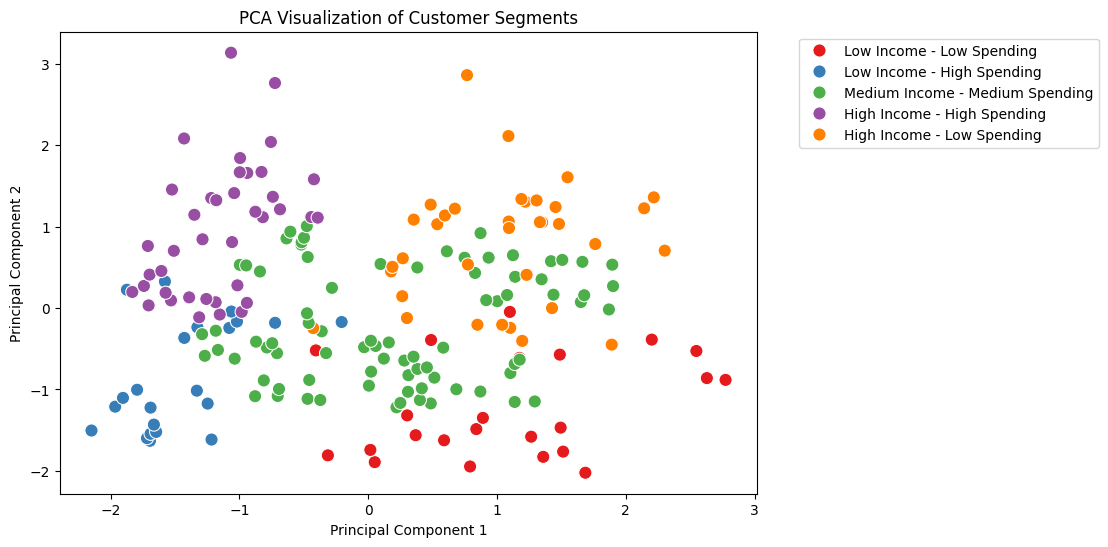

In [32]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="pca_1",
    y="pca_2",
    hue="segment_name",
    palette="Set1",
    s=90
)

plt.title("PCA Visualization of Customer Segments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## **8. t-SNE Visualization**

t-SNE is another dimensionality reduction technique useful for visualizing complex cluster patterns.


### **Apply t-SNE**

In [33]:
# Apply t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

X_tsne = tsne.fit_transform(X_multi_scaled)

# Add t-SNE results to dataframe
df["tsne_1"] = X_tsne[:, 0]
df["tsne_2"] = X_tsne[:, 1]

df.head()

,customer_id,gender,age,Education,Marital Status,annual_income,spending_score,gender_encoded,cluster,segment_name,pca_1,pca_2,tsne_1,tsne_2
0,1,M,19,High School,Married,15,39,0,4,Low Income - Low Spending,-0.406383,-0.520714,-9.011336,-10.541625
1,2,M,21,Graduate,Single,15,81,0,2,Low Income - High Spending,-1.427673,-0.367310,-10.227716,-9.141724
2,3,F,20,Graduate,Married,16,6,1,4,Low Income - Low Spending,0.050761,-1.894068,8.286118,10.705958
3,4,F,23,High School,Unknown,16,77,1,2,Low Income - High Spending,-1.694513,-1.631908,2.200941,12.100324
4,5,F,31,Uneducated,Married,17,40,1,4,Low Income - Low Spending,-0.313108,-1.810483,6.968685,9.885094



### **t-SNE Cluster Visualization**


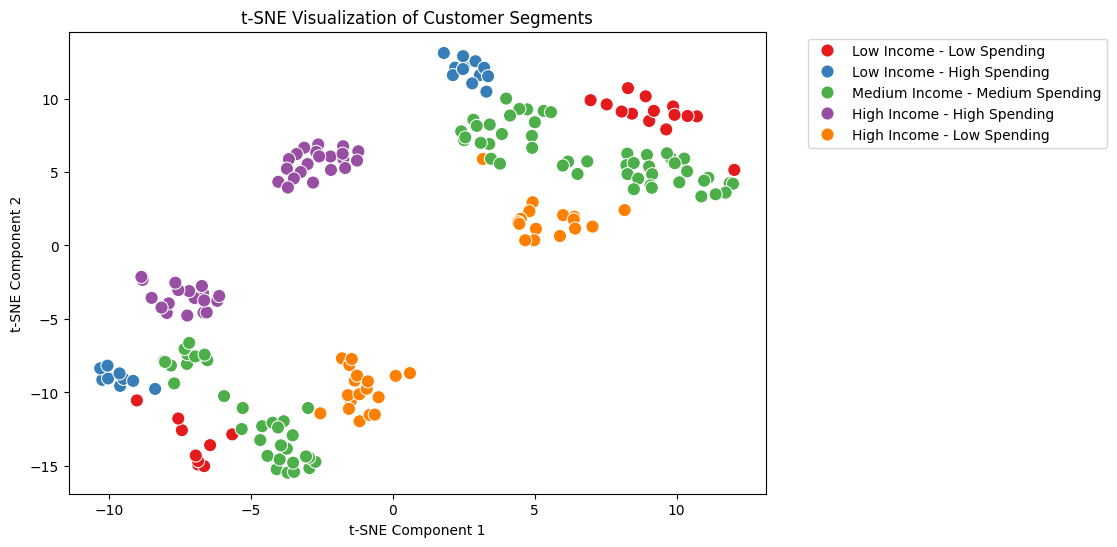

In [34]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="tsne_1",
    y="tsne_2",
    hue="segment_name",
    palette="Set1",
    s=90
)

plt.title("t-SNE Visualization of Customer Segments")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## **9. Marketing Strategies for Each Segment**

### **Cell 30 — Segment Summary Table**

In [35]:
strategy_table = pd.DataFrame({
    "Segment": [
        "High Income - High Spending",
        "High Income - Low Spending",
        "Low Income - High Spending",
        "Low Income - Low Spending",
        "Medium Income - Medium Spending"
    ],
    "Customer Behavior": [
        "Customers have strong buying power and already spend heavily.",
        "Customers have high income but do not spend much in the mall.",
        "Customers have limited income but still show high spending behavior.",
        "Customers have low income and low spending activity.",
        "Customers show average income and average spending behavior."
    ],
    "Marketing Strategy": [
        "Offer premium memberships, luxury product promotions, VIP experiences, early access to new collections, and loyalty rewards.",
        "Use personalized offers, exclusive discounts, premium product trials, and targeted campaigns to convert them into active spenders.",
        "Provide discounts, bundle offers, cashback deals, seasonal promotions, and affordable loyalty programs.",
        "Use budget-friendly promotions, basic discount campaigns, essential product offers, and low-cost engagement strategies.",
        "Use general loyalty programs, moderate discounts, cross-selling, and personalized recommendations to increase spending gradually."
    ]
})

strategy_table

,Segment,Customer Behavior,Marketing Strategy
0,High Income - High Spending,Customers have strong buying power and already...,"Offer premium memberships, luxury product prom..."
1,High Income - Low Spending,Customers have high income but do not spend mu...,"Use personalized offers, exclusive discounts, ..."
2,Low Income - High Spending,Customers have limited income but still show h...,"Provide discounts, bundle offers, cashback dea..."
3,Low Income - Low Spending,Customers have low income and low spending act...,"Use budget-friendly promotions, basic discount..."
4,Medium Income - Medium Spending,Customers show average income and average spen...,"Use general loyalty programs, moderate discoun..."


### **Display Cluster Profiles with Strategy**

In [36]:
# Merge cluster profile with segment names
final_cluster_summary = cluster_profile_reset.merge(
    strategy_table,
    left_on="segment_name",
    right_on="Segment",
    how="left"
)

final_cluster_summary

,cluster,age,annual_income,spending_score,gender_encoded,customer_count,segment_name,Segment,Customer Behavior,Marketing Strategy
0,0,42.716049,55.296296,49.518519,0.592593,81,Medium Income - Medium Spending,Medium Income - Medium Spending,Customers show average income and average spen...,"Use general loyalty programs, moderate discoun..."
1,1,32.692308,86.538462,82.128205,0.538462,39,High Income - High Spending,High Income - High Spending,Customers have strong buying power and already...,"Offer premium memberships, luxury product prom..."
2,2,25.272727,25.727273,79.363636,0.590909,22,Low Income - High Spending,Low Income - High Spending,Customers have limited income but still show h...,"Provide discounts, bundle offers, cashback dea..."
3,3,41.114286,88.200000,17.114286,0.457143,35,High Income - Low Spending,High Income - Low Spending,Customers have high income but do not spend mu...,"Use personalized offers, exclusive discounts, ..."
4,4,45.217391,26.304348,20.913043,0.608696,23,Low Income - Low Spending,Low Income - Low Spending,Customers have low income and low spending act...,"Use budget-friendly promotions, basic discount..."


## **10. Final Conclusion and Insights**

Final Conclusion:

This project used unsupervised learning to segment mall customers based on their income and spending behavior.

The dataset was first loaded, cleaned, and explored through EDA. No major missing value issues were found.
The gender column was encoded, and numerical features were scaled before clustering.

K-Means Clustering was applied to group customers into meaningful segments.
The Elbow Method and Silhouette Score were used to help identify the appropriate number of clusters.
Based on the analysis, 5 clusters were selected.

The main customer segments identified were:

1. High Income - High Spending
   These are premium customers. They are highly valuable and should be targeted with VIP offers,
   premium products, loyalty benefits, and exclusive experiences.

2. High Income - Low Spending
   These customers have strong purchasing power but are not spending much.
   The business should use personalized campaigns, premium trials, and targeted discounts to increase conversion.

3. Low Income - High Spending
   These customers spend actively despite lower income.
   They are suitable for discounts, bundles, cashback offers, and affordable loyalty programs.

4. Low Income - Low Spending
   These customers have limited income and low engagement.
   The best strategy is to use budget-friendly promotions and essential product offers.

5. Medium Income - Medium Spending
   These are average customers with growth potential.
   The business can increase their spending through loyalty programs, cross-selling, and personalized recommendations.

PCA and t-SNE were used to visualize the clusters in two dimensions.
The visualizations showed that customer groups have clear behavioral differences.

Overall, customer segmentation allows the mall to avoid generic marketing.
Instead, it can create targeted campaigns for each customer group, improving customer engagement,
sales performance, and marketing efficiency.